## Uczenie maszynowe – zastosowania
### Zajęcia laboratoryjne
# 3. Regresja liniowa – zadanie

## Zadanie 3

### Część podstawowa (4 punkty)

Plik `fires_thefts.csv` zawiera rzeczywiste dane zebrane przez *U.S. Commission on Civil Rights*, przedstawiające liczbę pożarów w danej dzielnicy na tysiąc gospodarstw domowych (pierwsza kolumna) oraz liczbę włamań w tej samej dzielnicy na tysiąc mieszkańców (druga kolumna). 

Stwórz model (regresja liniowa) przewidujący liczbę włamań na podstawie liczby pożarów:
 * Oblicz parametry $\theta$ krzywej regresyjnej za pomocą metody gradientu prostego (*gradient descent*). Możesz wybrać wersję iteracyjną lub macierzową algorytmu.
 * Wykorzystując uzyskaną krzywą regresyjną przepowiedz liczbę włamań na tysiąc mieszkańców dla dzielnicy, w której występuje średnio 50, 100, 200 pożarów na tysiąc gospodarstw domowych.

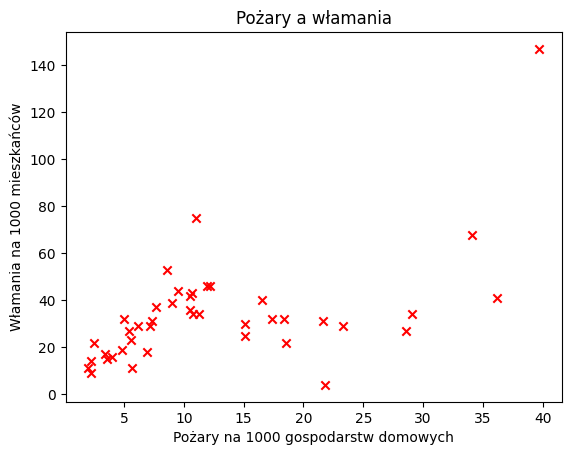

Liczba przykładów: 42
Pożary – min: 2.0, max: 39.7
Włamania – min: 4.0, max: 147.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Wczytanie danych
data = np.loadtxt('fires_thefts.csv', delimiter=',')
x = data[:, 0]  # pożary
y = data[:, 1]  # włamania

# Wizualizacja danych
plt.scatter(x, y, marker='x', color='red')
plt.xlabel('Pożary na 1000 gospodarstw domowych')
plt.ylabel('Włamania na 1000 mieszkańców')
plt.title('Pożary a włamania')
plt.show()

print(f"Liczba przykładów: {len(x)}")
print(f"Pożary – min: {x.min():.1f}, max: {x.max():.1f}")
print(f"Włamania – min: {y.min():.1f}, max: {y.max():.1f}")

In [2]:
# Normalizacja cech (feature scaling)
x_mean = np.mean(x)
x_std = np.std(x)
x_norm = (x - x_mean) / x_std

# Macierz X z kolumną jedynek (bias)
m = len(x)
X = np.column_stack([np.ones(m), x_norm])

# Funkcja kosztu J(theta)
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

# Gradient descent
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        gradient = (1 / m) * (X.T @ (X @ theta - y))
        theta = theta - alpha * gradient
        cost_history[i] = compute_cost(X, y, theta)
    return theta, cost_history

# Parametry
alpha = 0.01
iterations = 1000
theta_init = np.zeros(2)

# Uruchomienie gradient descent
theta, cost_history = gradient_descent(X, y, theta_init, alpha, iterations)

print(f"Wyznaczone parametry θ:")
print(f"  θ₀ = {theta[0]:.4f}")
print(f"  θ₁ = {theta[1]:.4f}")
print(f"\nKoszt końcowy J(θ) = {cost_history[-1]:.4f}")

Wyznaczone parametry θ:
  θ₀ = 33.6652
  θ₁ = 12.5455

Koszt końcowy J(θ) = 180.4101


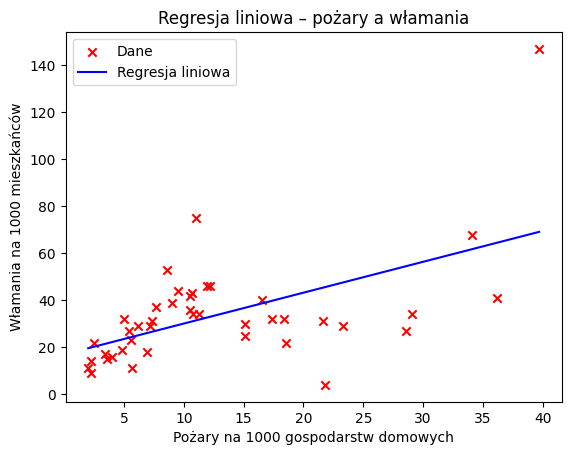

Dla 50 pożarów na 1000 gospodarstw → przewidywana liczba włamań: 82.66 na 1000 mieszkańców
Dla 100 pożarów na 1000 gospodarstw → przewidywana liczba włamań: 148.33 na 1000 mieszkańców
Dla 200 pożarów na 1000 gospodarstw → przewidywana liczba włamań: 279.67 na 1000 mieszkańców


In [3]:
# Wykres danych z krzywą regresji
plt.scatter(x, y, marker='x', color='red', label='Dane')
x_plot = np.linspace(x.min(), x.max(), 100)
x_plot_norm = (x_plot - x_mean) / x_std
y_plot = theta[0] + theta[1] * x_plot_norm
plt.plot(x_plot, y_plot, color='blue', label='Regresja liniowa')
plt.xlabel('Pożary na 1000 gospodarstw domowych')
plt.ylabel('Włamania na 1000 mieszkańców')
plt.title('Regresja liniowa – pożary a włamania')
plt.legend()
plt.show()

# Predykcje dla 50, 100, 200 pożarów
for fires in [50, 100, 200]:
    fires_norm = (fires - x_mean) / x_std
    prediction = theta[0] + theta[1] * fires_norm
    print(f"Dla {fires} pożarów na 1000 gospodarstw → przewidywana liczba włamań: {prediction:.2f} na 1000 mieszkańców")

### Część zaawansowana (2 punkty)

Dla różnych wartości długości kroku $\alpha \in \{ 0.001, 0.01 , 0.1 \}$ stwórz wykres, który zilustruje progresję wartości $J(\theta)$ dla pierwszych 200 króków algorytmu gradientu prostego:
 * Oś $x$ wykresu to kolejne kroki algorytmu – od 0 do 200.
 * Oś $y$ wykresu to wartosci $J(\theta)$.
 * Wykres powinien skłądać się z trzech krzywych:
   1. dla $\alpha = 0.001$
   2. dla $\alpha = 0.01$
   3. dla $\alpha = 0.1$

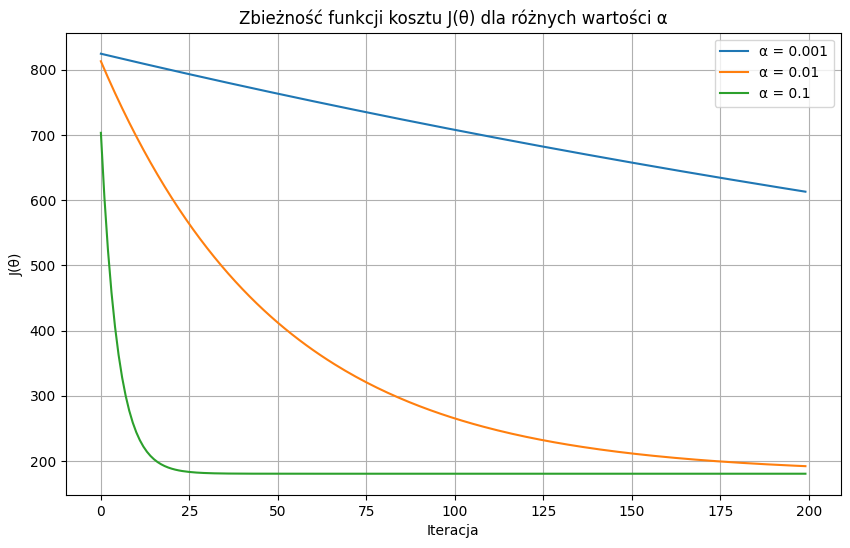

In [4]:
# Porównanie J(θ) dla różnych α
alphas = [0.001, 0.01, 0.1]
iterations_plot = 200

plt.figure(figsize=(10, 6))

for alpha_val in alphas:
    theta_init = np.zeros(2)
    _, cost_hist = gradient_descent(X, y, theta_init, alpha_val, iterations_plot)
    plt.plot(range(iterations_plot), cost_hist, label=f'α = {alpha_val}')

plt.xlabel('Iteracja')
plt.ylabel('J(θ)')
plt.title('Zbieżność funkcji kosztu J(θ) dla różnych wartości α')
plt.legend()
plt.grid(True)
plt.show()